# Project 2 - Sales Analysis - Visualisations

## Objectives

- Transform the Date column to pandas datetime
- Read data from combined csv file created from ETL processes
- Show plots to attempt to answer new hypothesis


## Inputs

CSV files used:

Sales_Combined_DataSet_Visualization.csv


## Outputs

Plots to show the data and attempt to answer the hypothesis


## Additional Comments

- Using as many of the plot libraries as possible to see which produces the best results for each hypothesis.
- Developed an experimental ETL library which is in this project (modETL_library.py)   
  Has lots of cool features so will be interesting to see how it works "in the field"

Used various AI tools to help with the visualisation process:
- ChatGPT
- GitHub Copilot

See Documents/What_AI_Used_For.md for more details.

Needed to install:

pip install nbformat

For plotly visualisations to work


- Isolated the visualisations into a seperate notebook to keep the file size as low as possible.


## Initalise Working Environment


In [3]:
#import libraries
import os
import numpy as np
import pandas as pd
import plotly.express as px
import seaborn as sns
import matplotlib.pyplot as plt

#added by me for visualisation fine tuning
from matplotlib.ticker import MultipleLocator

#added by me for plotly.express visualisation issue
import nbformat 


#below solution provided by chatGPT 
import sys
from pathlib import Path

project_root = Path.cwd().parent

if str(project_root / "assets" / "python_files") not in sys.path:
    sys.path.insert(0, str(project_root / "assets" / "python_files"))
    
import modGlobal
import modETL_Library as modETL
#end solution provided by chatGPT

# Hypothesis Being Tested

- What are the most profitable departments per store in the last 12 months?
- What are the top 10 stores in terms of profitability in the last 12 months?
- What are the bottom 10 stores in terms of profitability in the last 12 months?
- What are the predicted sales for store type A for next year?
- What are the predicted sales for stores in areas of high unemployment for next year?

# Section 1 - Initalisation

## Intitialise All Variables To Be Used In Global Stack 

In [4]:
#DataFrame vars for visualisation
dfSales_Combined_DataSet = None
dfSales_Combined_DataSet_Filtered = None

dfSunburst_DataSet = None
dfSales_Combined_DataSet_GroupBy = None

dfSales_Combined_DataSet_Work = None
dfSales_Combined_DataSet_Temp1 = None
dfSales_Combined_DataSet_Profit = None
dfSales_Combined_DataSet_HighestProfit = None

#other vars
lstStoreRanges = []
lstLabels = []
objStore = None
intYear = 0
fig = None
ax = None
intNum = 0
objCurrentStore  = None
lstMarkdownColumns = None
dictDataFrames = dict()


## Set Current Directory To Base Project Directory

In [5]:
#get project directory - default is jupyter notebook sub folder as that is where this file is located!
#so move back one to the project root path
# Source - https://stackoverflow.com/a/17726833
# Posted by chimpsarehungry
# Retrieved 2026-07-05, License - CC BY-SA 3.0

#get current folder
strCurrentDir = os.getcwd()

#is the last part of the path the project directory?
if not strCurrentDir.endswith(modGlobal.CNST_STR_PROJECT_DIR):
   #get current working directory and move back one to the project root path
   strCurrentDir =  os.path.normpath(os.getcwd() + os.sep + os.pardir)
   os.chdir(os.path.dirname(strCurrentDir))
   #change directory
   os.chdir(strCurrentDir)

#confirm current directory is project directory
print(f"Current Directory: \n {os.getcwd()}")

Current Directory: 
 /Users/rogerwilliams/Projects/Python/CourseProjects/Project2-SalesAnalysis


# Section 1 - Read Data From CSV File

- Read csv file

## Read csv File Into Variable For Processing and Copy Into dfSales_Combined_DataSet_Work

In [6]:
#read file from working files folder
#ETL library returns a dictionary of all files in the folder with the attribute name
#set to the actual csv filename
dictDataFrames = modETL.funcReadVisualisationFilesReturnDictionary()
#open into DataFrame which can be re-used during visualisations for filtering etc
dfSales_Combined_DataSet = dictDataFrames["Sales_Combined_DataSet_Visualisation.csv"]


4 csv Files Read Into DataFrames

DataFrames Created:
Sales_Combined_DataSet_Visualisation.csv
Features_DataSet_Visualisation.csv
Sales_DataSet_Visualisation.csv
Stores_DataSet_Visualisation.csv




## Transform Date Column To Datetime Format

In [7]:

#transform Date to datetime
dfSales_Combined_DataSet["Date"] = pd.to_datetime(dfSales_Combined_DataSet["Date"], format="%d/%m/%Y")

#check schema
dfSales_Combined_DataSet.dtypes

#create a working copy of the base DataFrame
dfSales_Combined_DataSet_Work = dfSales_Combined_DataSet.copy()

## Visualisations!

Each hypothesis will be visualised using which ever one of these looks best(!):

- pandas
- matplotlib.pyplot
- plotly.express
- seaborn


# Hypothesis 7

What are the most profitable departments per store in the last 12 months?

**Note:** last year in data is: 2012

## Visualisation library: Plotly Express

In [8]:
#find most profitable departments per store in the last 12 months

#first filter by year 2012
dfSales_Combined_DataSet_Filtered = dfSales_Combined_DataSet_Work[dfSales_Combined_DataSet_Work['Date'].dt.year == 2012]

#code created by chatGPT modified by me to suit naming conventions etc
dfSales_Combined_DataSet_Profit= (
    dfSales_Combined_DataSet_Filtered
    .groupby(["Store", "Dept"])["Weekly_Sales"]
    .sum()
    .reset_index()
)

dfSales_Combined_DataSet_HighestProfit = (
    dfSales_Combined_DataSet_Profit.loc[dfSales_Combined_DataSet_Profit.groupby("Store")["Weekly_Sales"].idxmax()]
    .sort_values("Store")
)

#sort by Store added by me
dfSales_Combined_DataSet_HighestProfit.sort_values(by="Store", ascending=True, inplace=True)

#show plot
plt.figure(figsize=(12, 8))

dfSales_Combined_DataSet_HighestProfit["Store_Dept"] = (
    "Store " + dfSales_Combined_DataSet_HighestProfit["Store"].astype(str) +
    " - Dept " + dfSales_Combined_DataSet_HighestProfit["Dept"].astype(str)
)

#changed chatGPT seaborn plot to the much better looking plotly express one
fig =px.bar(
    dfSales_Combined_DataSet_HighestProfit,
    x="Weekly_Sales",
    y="Store_Dept",
    orientation="h",
    color="Weekly_Sales",
    color_continuous_scale="Blues",
    title="Highest Selling Department For Each Store For Last 12 Months",
    #set plot size
    height=1000,
    width=1050
)

fig.update_layout(
    xaxis_title="Total Sales (£)",
    yaxis_title="Store and Department",
    yaxis=dict(autorange="reversed"),  # Reverse the y-axis to have the highest sales at the top
    coloraxis_colorbar=dict(title="Total Sales (£)"),
    title_x=0.5,  # Center the title
    font=dict(size=12),  # Set font size for better readability
)
fig.show()
                                                                  

<Figure size 1200x800 with 0 Axes>

# Observations

The plot shows the department with the highest total sales for store during 2012
First issue is the hypothesis uses the term "profitable" but the data has no profit or cost data so can only use Weekl_Sales  
as the source of financial information!
chatGPT's solution works but it seems beyond pandas to actually get the top 5 departments per store, well at least is shows  
the top departments

# Hypothesis 8

What are the top 10 stores in terms of profitability in the last 12 months?

**Note:** last year in data is: 2012

<Figure size 1000x600 with 0 Axes>

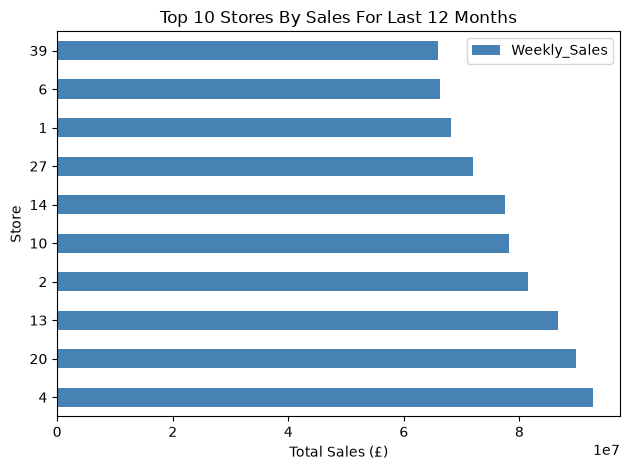

In [ ]:
#what are the top 10 stores in terms of profitability in the last 12 months?

#first filter by year 2012
dfSales_Combined_DataSet_Filtered = dfSales_Combined_DataSet_Work[dfSales_Combined_DataSet_Work['Date'].dt.year == 2012]

#group by Store and get sum of Weekly_Sales
dfSales_Combined_DataSet_Filtered = (
    dfSales_Combined_DataSet_Filtered
    .groupby("Store")["Weekly_Sales"]
    .sum()
    .sort_values(ascending=False)
    .head(10)
    .reset_index()
)

plt.figure(figsize=(10, 6))

dfSales_Combined_DataSet_Filtered.sort_values("Weekly_Sales", ascending=False).head(10).plot(
    x="Store",
    y="Weekly_Sales",
    kind="barh",
    color="steelblue"   
)

plt.title("Top 10 Stores By Sales For Last 12 Months")
plt.xlabel("Total Sales (£)")
plt.ylabel("Store")

plt.tight_layout()
plt.show()



# Observations

The plot shows the top 10 stores with the most sales correctly
First issue is the hypothesis uses the term "profitable" but the data has no profit or cost data so can only use Weekl_Sales  
as the source of financial information!
Originally used ploty express but it kept including stores with no data causing massive gaps in the chart


# Hypothesis 9

What are the bottom 10 stores in terms of profitability in the last 12 months?

<Figure size 1000x600 with 0 Axes>

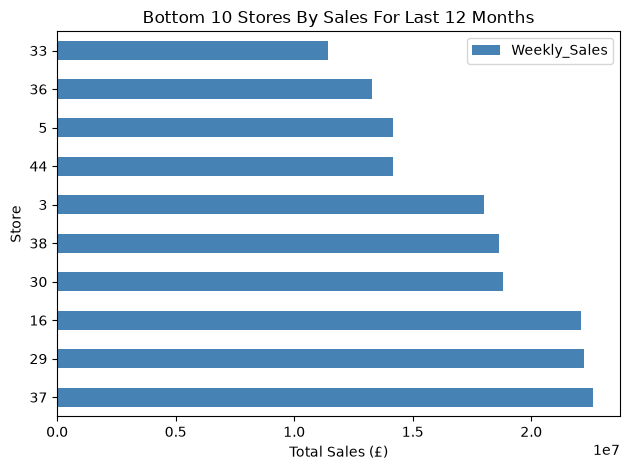

In [21]:
#what are the top 10 stores in terms of profitability in the last 12 months?

#first filter by year 2012
dfSales_Combined_DataSet_Filtered = dfSales_Combined_DataSet_Work[dfSales_Combined_DataSet_Work['Date'].dt.year == 2012]

#group by Store and get sum of Weekly_Sales
dfSales_Combined_DataSet_Filtered = (
    dfSales_Combined_DataSet_Filtered
    .groupby("Store")["Weekly_Sales"]
    .sum()
    .sort_values(ascending=False)
    .tail(10)
    .reset_index()
)

plt.figure(figsize=(10, 6))

dfSales_Combined_DataSet_Filtered.sort_values("Weekly_Sales", ascending=False).head(10).plot(
    x="Store",
    y="Weekly_Sales",
    kind="barh",
    color="steelblue"   
)

plt.title("Bottom 10 Stores By Sales For Last 12 Months")
plt.xlabel("Total Sales (£)")
plt.ylabel("Store")

plt.tight_layout()
plt.show()



# Observations

The plot shows the bottom 10 stores with the least sales correctly
First issue is the hypothesis uses the term "profitable" but the data has no profit or cost data so can only use Weekl_Sales  
as the source of financial information!
Originally used ploty express but it kept including stores with no data causing massive gaps in the chart